# Imports

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

In [3]:
import sklearn
print(sklearn.__version__)

1.2.2


# Data Frame Initial Processing

In [4]:
df=pd.read_csv('project_excel_edited.csv')

In [5]:
df.drop('Timestamp', axis=1, inplace=True)

In [6]:
df.drop(df.columns[0], axis=1, inplace=True)

In [7]:
df.head()

,What is your age?,What is your Gender?,What is your Occupation?,"How many hours per day, on average, do you spend on digital devices (smartphones, computers, tablets)?",Which digital device do you use most frequently?,How often do you check your smartphone within an hour of waking up?,How often do you check your smartphone within an hour of going to bed?,Do you use technology for work or academic purposes?,How often do you use social media platforms?,How many hours per day do you typically spend watching TV or streaming services?,...,How did you feel during your digital detox?,"Did you set specific goals or rules for your digital detox? (e.g., no social media, no screens after a certain hour)",Would you consider making digital detox a regular practice in your life?,How did your digital detox experience impact your subsequent use of technology?,"What is the biggest challenge that you faced during your digital detox, if any?",How do you manage stress related to technology?,"On a scale from 1 to 5, how effective do you find these strategies in managing stress related to technology?","How often do you engage in physical activities (e.g., exercise, yoga) as a self-care practice to manage stress?","Are there any particular outdoor activities you find helpful in reducing stress related to technology? (e.g., walking, hiking, gardening)",What are your coping strategies for technology-related stress?
0,23,Male,Student,5-6 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,No significant change,Yes,Yes,Used technology less,Difficulty staying disconnected,Set specific time limits for technology use,4,Frequently,No,I prefer to cope alone
1,23,Female,Student,More than 6 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,No change,Social pressure to stay connected,Engage in outdoor activities,4,Occasionally,Yes,I prefer to cope alone
2,31,Male,Student,5-6 hours,Computer/Laptop,Always,Always,Yes,Multiple times a day,More than 6 hours,...,I have never practiced digital detox,No,No,I have never practiced digital detox,I have never practiced digital detox,I sleep,1,Never,No,I sleep very much
3,23,Male,Employed (full-time),5-6 hours,Smartphone,Always,Always,Yes,Multiple times a day,1-2 hours,...,I have never practiced digital detox,No,Yes,I have never practiced digital detox,I have never practiced digital detox,Take short breaks from screens,2,Rarely,No,I prefer to cope alone
4,18,Female,Student,More than 6 hours,Smartphone,Often,Often,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,No change,Difficulty staying disconnected,Talk to friends or family about technology-rel...,3,Rarely,Yes,I seek support from friends or family


In [8]:
# List of new column names in the desired order
new_column_names = [
    'Age',
    'Gender',
    'Occupation',
    'Daily_device_hour',
    'Most_frequently_used_device',
    'Smartphone_check_frequency_wakeup',
    'Smartphone_check_frequency_bedtime',
    'Uses_tech_for_work_or_academic',
    'Social_media_frequency',
    'Daily_tv_streaming_hours',
    'Tech_for_relaxation_or_entertainment',
    'Most_frequent_online_content',
    'Emotions_associated_with_tech',
    'Mental_wellbeing_rating',
    'Emotional_symptoms_frequency',
    'Concentration_decision_difficulty_frequency',
    'Sleep_quality',
    'Changes_in_appetite_or_weight',
    'Physical_symptoms_frequency',
    'Energy_motivation_rating',
    'Interest_in_activities',
    'Stress_overwhelm_frequency',
    'Isolation_feeling',
    'Has_mental_health_support',
    'Mental_wellbeing_activities_frequency',
    'Digital_detox_taken',
    'Longest_digital_detox_duration',
    'Digital_detox_motivation',
    'Digital_detox_emotional_experience',
    'Digital_detox_goals_set',
    'Consider_regular_digital_detox',
    'Digital_detox_impact_on_tech_use',
    'Digital_detox_challenges',
    'Tech_stress_management',
    'Tech_stress_management_effectiveness',
    'Physical_activities_for_stress_management',
    'Outdoor_activities_to_reduce_tech_stress',
    'Tech_stress_coping_strategies',
]

df.columns = new_column_names

# Pandas Profiling

In [9]:
# from pandas_profiling import ProfileReport
from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='output.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
df.head(10)

,Age,Gender,Occupation,Daily_device_hour,Most_frequently_used_device,Smartphone_check_frequency_wakeup,Smartphone_check_frequency_bedtime,Uses_tech_for_work_or_academic,Social_media_frequency,Daily_tv_streaming_hours,...,Digital_detox_emotional_experience,Digital_detox_goals_set,Consider_regular_digital_detox,Digital_detox_impact_on_tech_use,Digital_detox_challenges,Tech_stress_management,Tech_stress_management_effectiveness,Physical_activities_for_stress_management,Outdoor_activities_to_reduce_tech_stress,Tech_stress_coping_strategies
0,23,Male,Student,5-6 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,No significant change,Yes,Yes,Used technology less,Difficulty staying disconnected,Set specific time limits for technology use,4,Frequently,No,I prefer to cope alone
1,23,Female,Student,More than 6 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,No change,Social pressure to stay connected,Engage in outdoor activities,4,Occasionally,Yes,I prefer to cope alone
2,31,Male,Student,5-6 hours,Computer/Laptop,Always,Always,Yes,Multiple times a day,More than 6 hours,...,I have never practiced digital detox,No,No,I have never practiced digital detox,I have never practiced digital detox,I sleep,1,Never,No,I sleep very much
3,23,Male,Employed (full-time),5-6 hours,Smartphone,Always,Always,Yes,Multiple times a day,1-2 hours,...,I have never practiced digital detox,No,Yes,I have never practiced digital detox,I have never practiced digital detox,Take short breaks from screens,2,Rarely,No,I prefer to cope alone
4,18,Female,Student,More than 6 hours,Smartphone,Often,Often,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,No change,Difficulty staying disconnected,Talk to friends or family about technology-rel...,3,Rarely,Yes,I seek support from friends or family
5,25,Male,Employed (part-time),5-6 hours,Smartphone,Often,Occasionally,Yes,Multiple times a day,1-2 hours,...,Relaxed and refreshed,Yes,Yes,Used technology more mindfully,Boredom,Take short breaks from screens,4,Frequently,Yes,I seek support from friends or family
6,20,Male,Student,3-4 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,Used technology more mindfully,Boredom,Take short breaks from screens,4,Always,Yes,I seek support from friends or family
7,24,Female,Student,More than 6 hours,Computer/Laptop,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,No significant change,No,No,No change,Boredom,Take short breaks from screens,3,Never,No,I prefer to cope alone
8,17,Female,Student,1-2 hours,Smartphone,Often,Occasionally,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,Used technology more mindfully,FOMO (Fear of Missing Out),Engage in outdoor activities,3,Occasionally,Yes,I prefer to cope alone
9,"16 years, 11 months",Male,Student,More than 6 hours,Computer/Laptop,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,Anxious or stressed,No,No,No change,Boredom,Spending time with friends at school and coaching,4,Never,Yes,I prefer to cope alone


In [11]:
# Conversion of Mental wellbeing rating into 1) 3 class 2) Binary class

# Conversion of Mental wellbeing rating into 3 classes
for i in range(len(df['Mental_wellbeing_rating'])):
    rating = df['Mental_wellbeing_rating'].iloc[i]
    if rating < 3:
        df['Mental_wellbeing_rating'].iloc[i] = 0
    elif rating == 3:
        df['Mental_wellbeing_rating'].iloc[i] = 1
    else:
        df['Mental_wellbeing_rating'].iloc[i] = 2

        
        

In [12]:
df['Mental_wellbeing_rating'].value_counts()

1    243
0    188
2    182
Name: Mental_wellbeing_rating, dtype: int64

Regular Expression used to extract digits from Age Column

In [13]:
#Regular Expression used to extract digits from Age Column
df['Age'] = df['Age'].str.extract('(\d+)', expand=False)


In [14]:
df['Age']=df['Age'].astype('float64')

In [15]:
df.head(10)

,Age,Gender,Occupation,Daily_device_hour,Most_frequently_used_device,Smartphone_check_frequency_wakeup,Smartphone_check_frequency_bedtime,Uses_tech_for_work_or_academic,Social_media_frequency,Daily_tv_streaming_hours,...,Digital_detox_emotional_experience,Digital_detox_goals_set,Consider_regular_digital_detox,Digital_detox_impact_on_tech_use,Digital_detox_challenges,Tech_stress_management,Tech_stress_management_effectiveness,Physical_activities_for_stress_management,Outdoor_activities_to_reduce_tech_stress,Tech_stress_coping_strategies
0,23.0,Male,Student,5-6 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,No significant change,Yes,Yes,Used technology less,Difficulty staying disconnected,Set specific time limits for technology use,4,Frequently,No,I prefer to cope alone
1,23.0,Female,Student,More than 6 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,No change,Social pressure to stay connected,Engage in outdoor activities,4,Occasionally,Yes,I prefer to cope alone
2,31.0,Male,Student,5-6 hours,Computer/Laptop,Always,Always,Yes,Multiple times a day,More than 6 hours,...,I have never practiced digital detox,No,No,I have never practiced digital detox,I have never practiced digital detox,I sleep,1,Never,No,I sleep very much
3,23.0,Male,Employed (full-time),5-6 hours,Smartphone,Always,Always,Yes,Multiple times a day,1-2 hours,...,I have never practiced digital detox,No,Yes,I have never practiced digital detox,I have never practiced digital detox,Take short breaks from screens,2,Rarely,No,I prefer to cope alone
4,18.0,Female,Student,More than 6 hours,Smartphone,Often,Often,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,No change,Difficulty staying disconnected,Talk to friends or family about technology-rel...,3,Rarely,Yes,I seek support from friends or family
5,25.0,Male,Employed (part-time),5-6 hours,Smartphone,Often,Occasionally,Yes,Multiple times a day,1-2 hours,...,Relaxed and refreshed,Yes,Yes,Used technology more mindfully,Boredom,Take short breaks from screens,4,Frequently,Yes,I seek support from friends or family
6,20.0,Male,Student,3-4 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,Used technology more mindfully,Boredom,Take short breaks from screens,4,Always,Yes,I seek support from friends or family
7,24.0,Female,Student,More than 6 hours,Computer/Laptop,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,No significant change,No,No,No change,Boredom,Take short breaks from screens,3,Never,No,I prefer to cope alone
8,17.0,Female,Student,1-2 hours,Smartphone,Often,Occasionally,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,Used technology more mindfully,FOMO (Fear of Missing Out),Engage in outdoor activities,3,Occasionally,Yes,I prefer to cope alone
9,16.0,Male,Student,More than 6 hours,Computer/Laptop,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,Anxious or stressed,No,No,No change,Boredom,Spending time with friends at school and coaching,4,Never,Yes,I prefer to cope alone


# Converting user typed attributes to "others"

In [16]:
form_options = [
    "News and information",
    "Entertainment (videos, movies, music)",
    "Educational content",
    "Social media updates",
    "Work-related content",
    "Smartphone",
    "Computer/Laptop",
    "Tablet",
    "Feeling overwhelmed or stressed",
    "Noticing negative effects on mental health",
    "Focusing on in-person relationships",
    "Improving productivity",
    "Curiosity or personal experiment",
    "Relaxed and refreshed",
    "Anxious or stressed",
    "No significant change",
    "Used technology less",
    "No change",
    "Used technology more mindfully",
    "FOMO (Fear of Missing Out)",
    "Difficulty staying disconnected",
    "Social pressure to stay connected",
    "Boredom",
    "None, it was easy and enjoyable",
    "I have never practiced digital detox",
    "Take short breaks from screens",
    "Set specific time limits for technology use",
    "Engage in outdoor activities",
    "Practice mindfulness or meditation",
    "Talk to friends or family about technology-related stress",
    "Unplug from technology for a designated period",
    "Seek professional help or counseling",
    "I prefer to cope alone",
    "I seek support from friends or family",
    "I participate in online communities or forums",
    "I attend social events or gatherings",
]

target_cols = [
    'Most_frequently_used_device',
    'Most_frequent_online_content',
    'Digital_detox_motivation',
    'Digital_detox_emotional_experience',
    'Digital_detox_impact_on_tech_use',
    'Digital_detox_challenges',
    'Tech_stress_management',
    'Tech_stress_coping_strategies',
]

In [17]:
for col in target_cols:
    for value in df[col]:
        if value not in form_options:
            df[col].replace(value,"Others",inplace=True)

# Data Visualization

In [18]:
# extra code – code to save the figures as high-res PNGs
import os
from pathlib import Path

IMAGES_PATH = Path() / "images" / "Data Preprocessing"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Peak Age: 23.625
Spread (Standard Deviation): 3.5597719964227847
Skewness: 2.5093650668998824


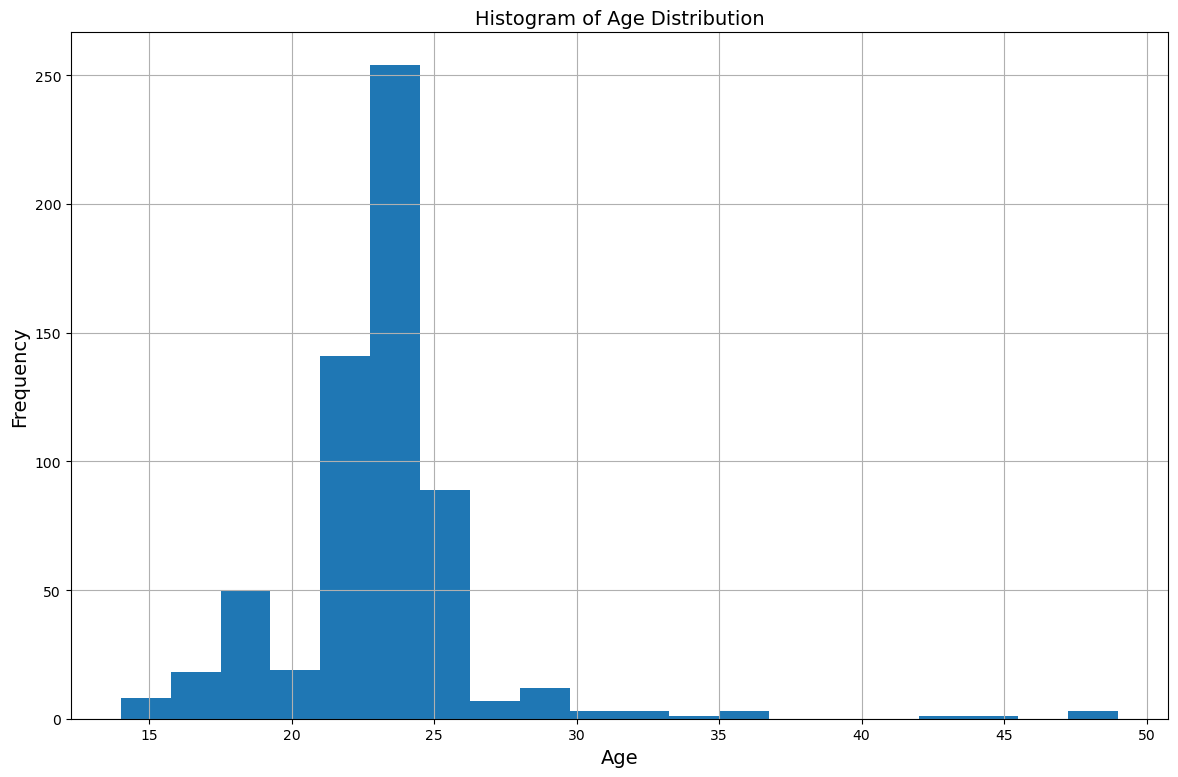

In [19]:
# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
df['Age'].hist(bins=20, figsize=(12, 8))
plt.title('Histogram of Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
save_fig("age_histogram")  # extra code
# Extracting information
bin_counts, bin_edges = np.histogram(df['Age'], bins=20)
peak_bin_index = np.argmax(bin_counts)
peak_age = (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1]) / 2
spread = np.std(df['Age'])
skewness = df['Age'].skew()

print(f"Peak Age: {peak_age}")
print(f"Spread (Standard Deviation): {spread}")
print(f"Skewness: {skewness}")
plt.show()

Median: 23.0
IQR: 2.0
Lower Whisker: 19.0
Upper Whisker: 27.0


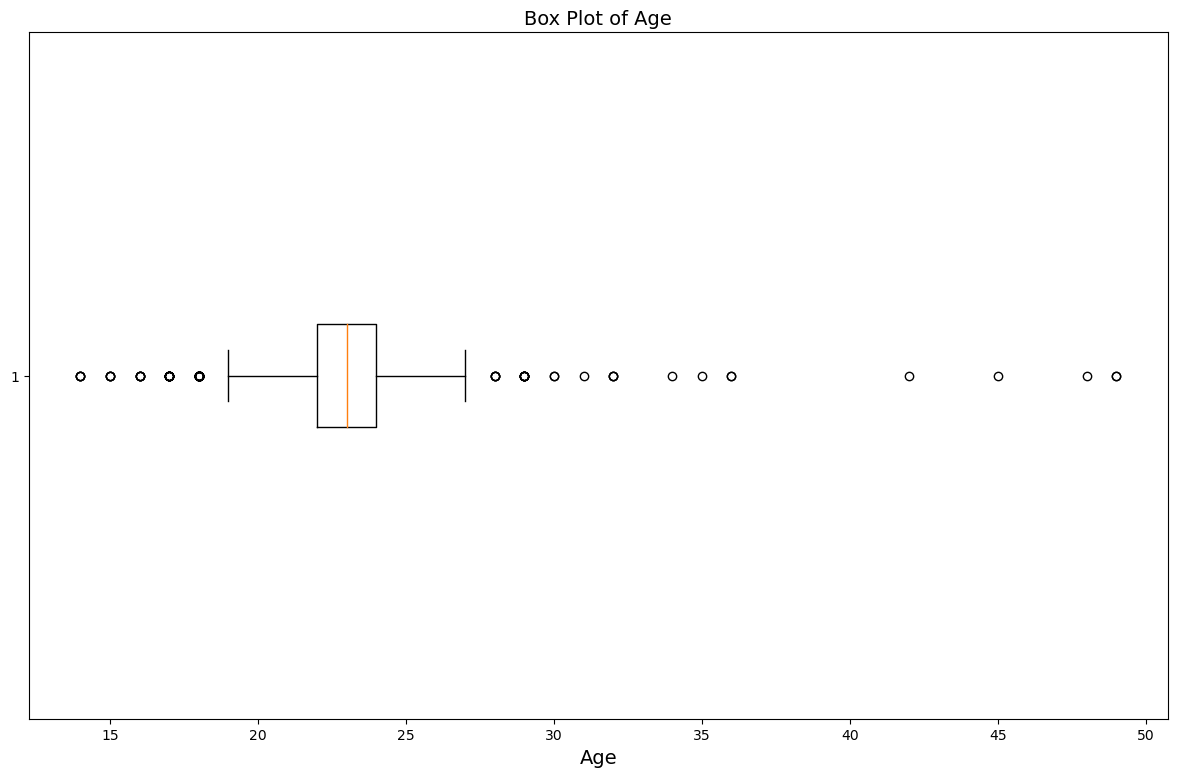

In [20]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)


plt.figure(figsize=(12, 8))
plt.boxplot(df['Age'], vert=False)
plt.title('Box Plot of Age')
plt.xlabel('Age')
# Extracting information
median = df['Age'].median()
iqr = df['Age'].quantile(0.75) - df['Age'].quantile(0.25)
lower_whisker = df['Age'].quantile(0.25) - 1.5 * iqr
upper_whisker = df['Age'].quantile(0.75) + 1.5 * iqr

print(f"Median: {median}")
print(f"IQR: {iqr}")
print(f"Lower Whisker: {lower_whisker}")
print(f"Upper Whisker: {upper_whisker}")
save_fig("age_boxplot")  # extra code
plt.show()

In [21]:
df.describe()

,Age,Mental_wellbeing_rating,Tech_stress_management_effectiveness
count,613.000000,613.000000,613.000000
mean,22.918434,0.990212,3.174551
std,3.562679,0.777483,0.982130
min,14.000000,0.000000,1.000000
25%,22.000000,0.000000,3.000000
50%,23.000000,1.000000,3.000000
75%,24.000000,2.000000,4.000000
max,49.000000,2.000000,5.000000


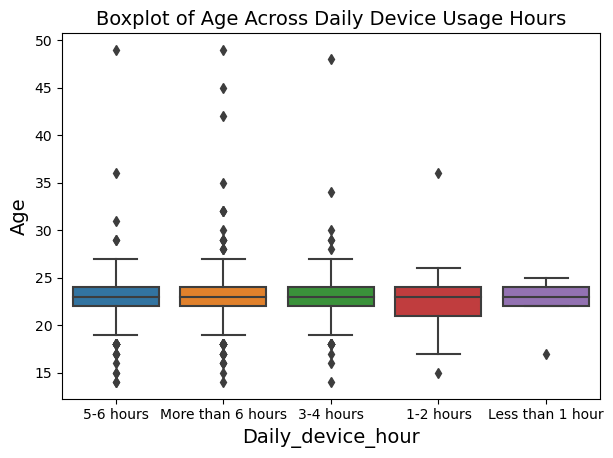

                   count       mean       std   min   25%   50%   75%   max
Daily_device_hour                                                          
1-2 hours           25.0  22.600000  3.785939  15.0  21.0  23.0  24.0  36.0
3-4 hours          134.0  22.925373  3.461120  14.0  22.0  23.0  24.0  48.0
5-6 hours          162.0  22.753086  3.570169  14.0  22.0  23.0  24.0  49.0
Less than 1 hour     5.0  22.200000  3.114482  17.0  22.0  23.0  24.0  25.0
More than 6 hours  287.0  23.048780  3.609097  14.0  22.0  23.0  24.0  49.0
                   lower_whisker  upper_whisker
Daily_device_hour                              
1-2 hours                   16.5           28.5
3-4 hours                   19.0           27.0
5-6 hours                   19.0           27.0
Less than 1 hour            19.0           27.0
More than 6 hours           19.0           27.0


In [22]:
sns.boxplot(x=df['Daily_device_hour'], y=df['Age'])
plt.title('Boxplot of Age Across Daily Device Usage Hours')
save_fig("daily_device_hours_boxplot")  # extra code
plt.show()
summary_stats = df.groupby('Daily_device_hour')['Age'].describe()
print(summary_stats)
summary_stats['lower_whisker'] = summary_stats['25%'] - 1.5 * (summary_stats['75%'] - summary_stats['25%'])
summary_stats['upper_whisker'] = summary_stats['75%'] + 1.5 * (summary_stats['75%'] - summary_stats['25%'])

print(summary_stats[['lower_whisker', 'upper_whisker']])

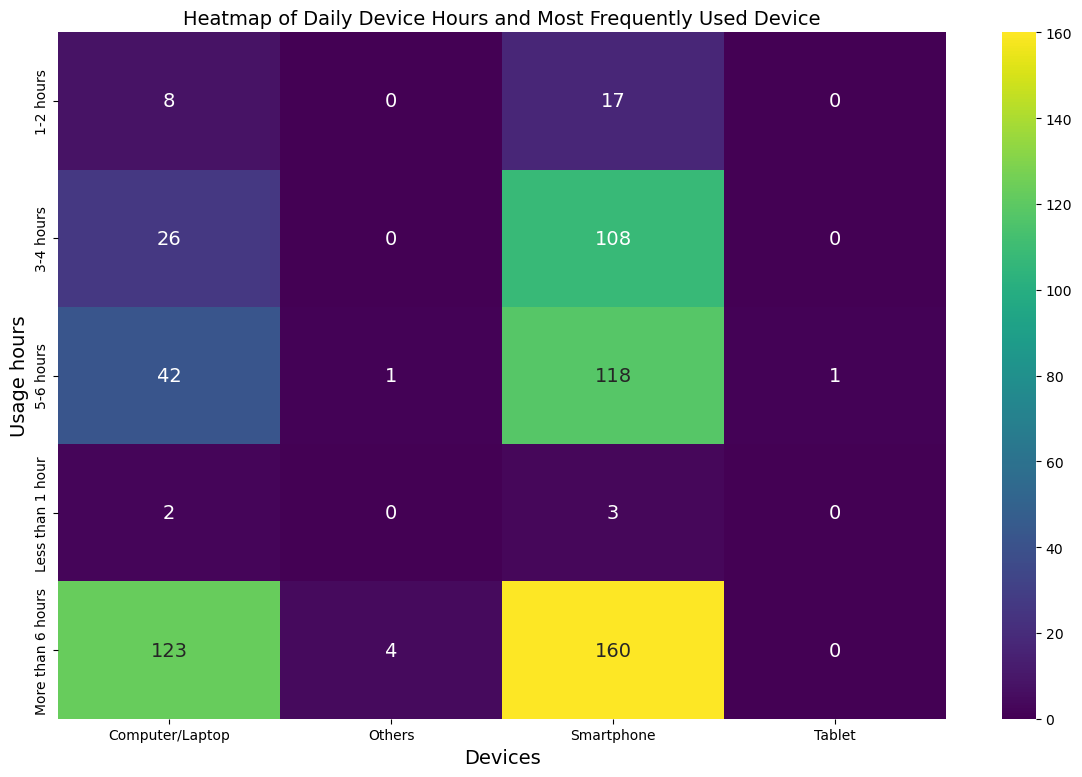

In [23]:
# Heatmap
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=8)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.figure(figsize=(12, 8))
cross_tab = pd.crosstab(df['Daily_device_hour'], df['Most_frequently_used_device'])
sns.heatmap(cross_tab, annot=True, cmap='viridis', fmt='d')
plt.title('Heatmap of Daily Device Hours and Most Frequently Used Device')
plt.xlabel('Devices')
plt.ylabel('Usage hours')
save_fig("most_freq_dev_hours")
plt.show()

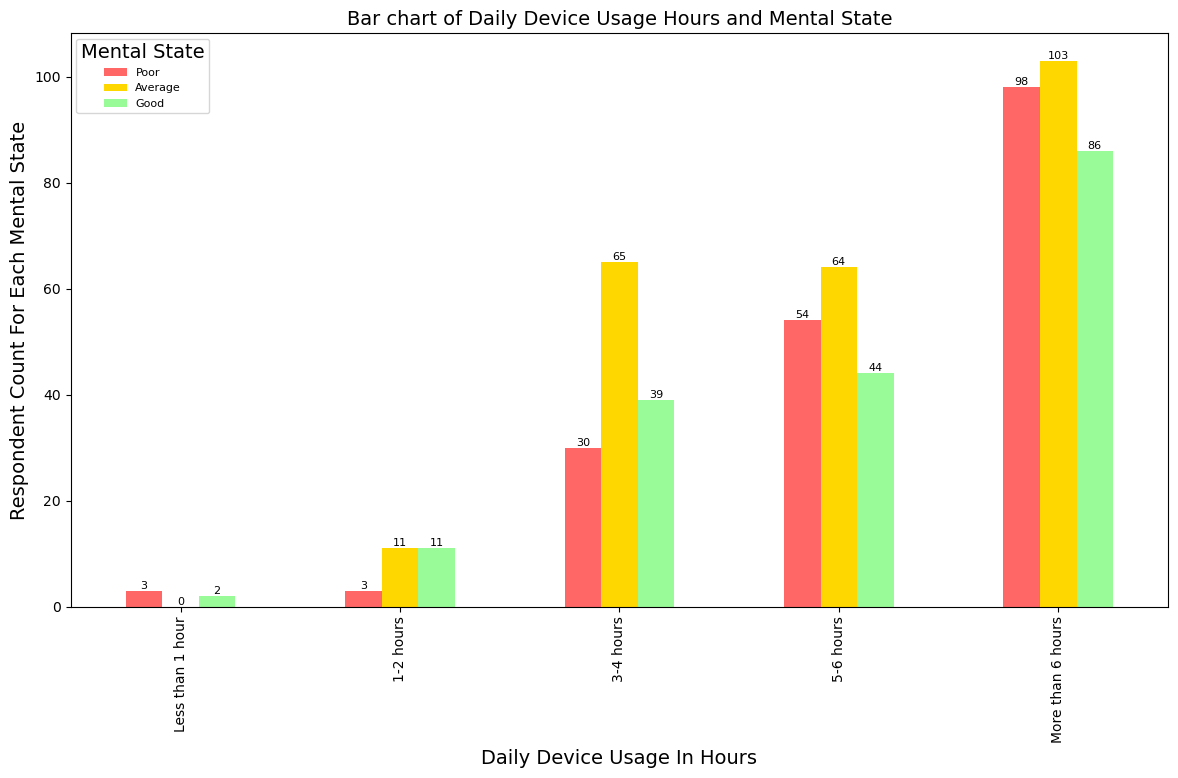

In [24]:
order = [
    'Less than 1 hour',
    '1-2 hours',
    '3-4 hours',
    '5-6 hours',
    'More than 6 hours'
]

# Convert 'Daily_device_hour' to categorical with the custom order
df['Daily_device_hour'] = pd.Categorical(df['Daily_device_hour'], categories=order, ordered=True)
cross_tab = pd.crosstab(df['Daily_device_hour'], df['Mental_wellbeing_rating'])
colors = ['#FF6666', '#FFD700', '#98FB98']

# Stacked Bar Plot
ax = cross_tab.plot(kind='bar', stacked=False, figsize=(12, 8),color=colors)

# Add value counts on top of each bar with a slight y-axis offset

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate(f'{height}', (x + width / 2, y + height), ha='center', va='bottom', fontsize=8)
legend_labels = ['Poor', 'Average', 'Good']
ax.legend(legend_labels, title='Mental State')
# Set plot details
plt.title('Bar chart of Daily Device Usage Hours and Mental State')
plt.xlabel('Daily Device Usage In Hours')
plt.ylabel('Respondent Count For Each Mental State')
save_fig('mental_rating_hours')
plt.show()

In [25]:
df.isnull().sum()

Age                                            0
Gender                                         0
Occupation                                     0
Daily_device_hour                              0
Most_frequently_used_device                    0
Smartphone_check_frequency_wakeup              0
Smartphone_check_frequency_bedtime             0
Uses_tech_for_work_or_academic                 0
Social_media_frequency                         0
Daily_tv_streaming_hours                       0
Tech_for_relaxation_or_entertainment           0
Most_frequent_online_content                   0
Emotions_associated_with_tech                  0
Mental_wellbeing_rating                        0
Emotional_symptoms_frequency                   0
Concentration_decision_difficulty_frequency    0
Sleep_quality                                  0
Changes_in_appetite_or_weight                  0
Physical_symptoms_frequency                    0
Energy_motivation_rating                       0
Interest_in_activiti

# Train Test Split Using Sk_learn

In [26]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.15,random_state=14)

In [27]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 521 entries, 278 to 344
Data columns (total 38 columns):
 #   Column                                       Non-Null Count  Dtype   
---  ------                                       --------------  -----   
 0   Age                                          521 non-null    float64 
 1   Gender                                       521 non-null    object  
 2   Occupation                                   521 non-null    object  
 3   Daily_device_hour                            521 non-null    category
 4   Most_frequently_used_device                  521 non-null    object  
 5   Smartphone_check_frequency_wakeup            521 non-null    object  
 6   Smartphone_check_frequency_bedtime           521 non-null    object  
 7   Uses_tech_for_work_or_academic               521 non-null    object  
 8   Social_media_frequency                       521 non-null    object  
 9   Daily_tv_streaming_hours                     521 non-null    ob

# Feature Scaling Age

In [28]:
from sklearn.preprocessing import MinMaxScaler
age_column_train = train_set['Age'].values.reshape(-1, 1)
age_column_test = test_set['Age'].values.reshape(-1, 1)
mms = MinMaxScaler()
train_set['Age'] = mms.fit_transform(age_column_train)
test_set['Age'] = mms.transform(age_column_test)

In [29]:
train_set['Age'].head()

278    0.285714
472    0.314286
428    0.257143
132    0.514286
444    0.228571
Name: Age, dtype: float64

In [30]:
test_set['Age'].head()

193    0.257143
102    0.257143
383    0.114286
72     0.257143
506    0.257143
Name: Age, dtype: float64

In [31]:
median_age = train_set['Age'].median()
print(median_age)

0.2571428571428572


In [32]:
train_set['Age'].fillna(median_age, inplace=True)
test_set['Age'].fillna(median_age, inplace=True)

In [33]:
test_set['Age'].head()

193    0.257143
102    0.257143
383    0.114286
72     0.257143
506    0.257143
Name: Age, dtype: float64

In [34]:
train_set['Age'].head()

278    0.285714
472    0.314286
428    0.257143
132    0.514286
444    0.228571
Name: Age, dtype: float64

In [35]:
train_set.isnull().sum()

Age                                            0
Gender                                         0
Occupation                                     0
Daily_device_hour                              0
Most_frequently_used_device                    0
Smartphone_check_frequency_wakeup              0
Smartphone_check_frequency_bedtime             0
Uses_tech_for_work_or_academic                 0
Social_media_frequency                         0
Daily_tv_streaming_hours                       0
Tech_for_relaxation_or_entertainment           0
Most_frequent_online_content                   0
Emotions_associated_with_tech                  0
Mental_wellbeing_rating                        0
Emotional_symptoms_frequency                   0
Concentration_decision_difficulty_frequency    0
Sleep_quality                                  0
Changes_in_appetite_or_weight                  0
Physical_symptoms_frequency                    0
Energy_motivation_rating                       0
Interest_in_activiti

In [36]:
test_set.isnull().sum()

Age                                            0
Gender                                         0
Occupation                                     0
Daily_device_hour                              0
Most_frequently_used_device                    0
Smartphone_check_frequency_wakeup              0
Smartphone_check_frequency_bedtime             0
Uses_tech_for_work_or_academic                 0
Social_media_frequency                         0
Daily_tv_streaming_hours                       0
Tech_for_relaxation_or_entertainment           0
Most_frequent_online_content                   0
Emotions_associated_with_tech                  0
Mental_wellbeing_rating                        0
Emotional_symptoms_frequency                   0
Concentration_decision_difficulty_frequency    0
Sleep_quality                                  0
Changes_in_appetite_or_weight                  0
Physical_symptoms_frequency                    0
Energy_motivation_rating                       0
Interest_in_activiti

In [37]:
train_set['Age'] = train_set['Age'].astype('float64')
test_set['Age'] = test_set['Age'].astype('float64')

In [38]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 521 entries, 278 to 344
Data columns (total 38 columns):
 #   Column                                       Non-Null Count  Dtype   
---  ------                                       --------------  -----   
 0   Age                                          521 non-null    float64 
 1   Gender                                       521 non-null    object  
 2   Occupation                                   521 non-null    object  
 3   Daily_device_hour                            521 non-null    category
 4   Most_frequently_used_device                  521 non-null    object  
 5   Smartphone_check_frequency_wakeup            521 non-null    object  
 6   Smartphone_check_frequency_bedtime           521 non-null    object  
 7   Uses_tech_for_work_or_academic               521 non-null    object  
 8   Social_media_frequency                       521 non-null    object  
 9   Daily_tv_streaming_hours                     521 non-null    ob

In [39]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 92 entries, 193 to 196
Data columns (total 38 columns):
 #   Column                                       Non-Null Count  Dtype   
---  ------                                       --------------  -----   
 0   Age                                          92 non-null     float64 
 1   Gender                                       92 non-null     object  
 2   Occupation                                   92 non-null     object  
 3   Daily_device_hour                            92 non-null     category
 4   Most_frequently_used_device                  92 non-null     object  
 5   Smartphone_check_frequency_wakeup            92 non-null     object  
 6   Smartphone_check_frequency_bedtime           92 non-null     object  
 7   Uses_tech_for_work_or_academic               92 non-null     object  
 8   Social_media_frequency                       92 non-null     object  
 9   Daily_tv_streaming_hours                     92 non-null     obj

# Targets and Labels

In [40]:
#Seperating Data into Targets and Labels.
x_train=train_set.drop(columns=['Mental_wellbeing_rating'])
x_test=test_set.drop(columns=['Mental_wellbeing_rating'])
y_train=train_set['Mental_wellbeing_rating']
y_test=test_set['Mental_wellbeing_rating']

In [41]:
x_train.head(20)

,Age,Gender,Occupation,Daily_device_hour,Most_frequently_used_device,Smartphone_check_frequency_wakeup,Smartphone_check_frequency_bedtime,Uses_tech_for_work_or_academic,Social_media_frequency,Daily_tv_streaming_hours,...,Digital_detox_emotional_experience,Digital_detox_goals_set,Consider_regular_digital_detox,Digital_detox_impact_on_tech_use,Digital_detox_challenges,Tech_stress_management,Tech_stress_management_effectiveness,Physical_activities_for_stress_management,Outdoor_activities_to_reduce_tech_stress,Tech_stress_coping_strategies
278,0.285714,Male,Student,More than 6 hours,Computer/Laptop,Always,Always,Yes,Multiple times a day,More than 6 hours,...,I have never practiced digital detox,No,No,I have never practiced digital detox,I have never practiced digital detox,Seek professional help or counseling,1,Rarely,Yes,I participate in online communities or forums
472,0.314286,Male,Employed (full-time),More than 6 hours,Computer/Laptop,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,No,Yes,Used technology more mindfully,FOMO (Fear of Missing Out),Take short breaks from screens,3,Frequently,Yes,I prefer to cope alone
428,0.257143,Female,Student,More than 6 hours,Smartphone,Often,Often,Yes,Multiple times a day,Less than 1 hour,...,No significant change,No,No,No change,FOMO (Fear of Missing Out),Talk to friends or family about technology-rel...,3,Rarely,No,I seek support from friends or family
132,0.514286,Female,Employed (full-time),More than 6 hours,Computer/Laptop,Always,Often,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,No,Yes,Used technology less,FOMO (Fear of Missing Out),Take short breaks from screens,4,Occasionally,Yes,I prefer to cope alone
444,0.228571,Male,Student,3-4 hours,Smartphone,Occasionally,Occasionally,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,Used technology less,Difficulty staying disconnected,Engage in outdoor activities,5,Occasionally,Yes,I seek support from friends or family
409,0.114286,Female,Student,More than 6 hours,Smartphone,Always,Always,Yes,Multiple times a day,3-4 hours,...,Relaxed and refreshed,No,Yes,No change,Boredom,Take short breaks from screens,2,Rarely,No,I prefer to cope alone
451,0.200000,Male,Student,More than 6 hours,Computer/Laptop,Occasionally,Always,Yes,Multiple times a day,More than 6 hours,...,Relaxed and refreshed,Yes,Yes,Used technology more mindfully,Boredom,Take short breaks from screens,4,Occasionally,Yes,I prefer to cope alone
601,0.228571,Male,Student,3-4 hours,Smartphone,Always,Always,Yes,Several times a week,1-2 hours,...,I have never practiced digital detox,No,No,I have never practiced digital detox,I have never practiced digital detox,Take short breaks from screens,5,Always,Yes,I prefer to cope alone
33,0.114286,Female,Student,5-6 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,Relaxed and refreshed,Yes,Yes,Used technology more mindfully,Social pressure to stay connected,Engage in outdoor activities,2,Occasionally,Yes,I attend social events or gatherings
32,0.114286,Female,Student,More than 6 hours,Smartphone,Always,Always,Yes,Multiple times a day,Less than 1 hour,...,No significant change,No,No,No change,Boredom,Take short breaks from screens,2,Never,No,I prefer to cope alone


In [42]:
y_train.head()

278    0
472    2
428    1
132    2
444    2
Name: Mental_wellbeing_rating, dtype: int64

In [43]:
# # Replacing age above 60 with median age.

# for age in x_train['Age']:
#     if(age>60):
#         x_train['Age'] = x_train['Age'].replace(age, median_age)
        
# for age in x_test['Age']:
#     if(age>60):
#         x_test['Age'] = x_test['Age'].replace(age, median_age)

# The Train Test Split Info
x_train and x_test contains all the features.
y_train and y_test contains Mental_wellbeing_rating

In [44]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 521 entries, 278 to 344
Data columns (total 37 columns):
 #   Column                                       Non-Null Count  Dtype   
---  ------                                       --------------  -----   
 0   Age                                          521 non-null    float64 
 1   Gender                                       521 non-null    object  
 2   Occupation                                   521 non-null    object  
 3   Daily_device_hour                            521 non-null    category
 4   Most_frequently_used_device                  521 non-null    object  
 5   Smartphone_check_frequency_wakeup            521 non-null    object  
 6   Smartphone_check_frequency_bedtime           521 non-null    object  
 7   Uses_tech_for_work_or_academic               521 non-null    object  
 8   Social_media_frequency                       521 non-null    object  
 9   Daily_tv_streaming_hours                     521 non-null    ob

In [45]:
y_train.info()

<class 'pandas.core.series.Series'>
Int64Index: 521 entries, 278 to 344
Series name: Mental_wellbeing_rating
Non-Null Count  Dtype
--------------  -----
521 non-null    int64
dtypes: int64(1)
memory usage: 8.1 KB


In [46]:
x_train.describe()

,Age,Tech_stress_management_effectiveness
count,521.000000,521.000000
mean,0.255169,3.170825
std,0.097371,0.984296
min,0.000000,1.000000
25%,0.228571,3.000000
50%,0.257143,3.000000
75%,0.285714,4.000000
max,1.000000,5.000000


In [47]:
x_test.describe()

,Age,Tech_stress_management_effectiveness
count,92.000000,92.000000
mean,0.252795,3.195652
std,0.124499,0.974839
min,0.028571,1.000000
25%,0.200000,3.000000
50%,0.257143,3.000000
75%,0.285714,4.000000
max,1.000000,5.000000


# Target Info
Mental_wellbeing_rating ranges from 1-5 
Mental wellbeing rating into 3 classes
 1-2:Poor
 3: Moderate
 4-5 Good

In [48]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 521 entries, 278 to 344
Data columns (total 37 columns):
 #   Column                                       Non-Null Count  Dtype   
---  ------                                       --------------  -----   
 0   Age                                          521 non-null    float64 
 1   Gender                                       521 non-null    object  
 2   Occupation                                   521 non-null    object  
 3   Daily_device_hour                            521 non-null    category
 4   Most_frequently_used_device                  521 non-null    object  
 5   Smartphone_check_frequency_wakeup            521 non-null    object  
 6   Smartphone_check_frequency_bedtime           521 non-null    object  
 7   Uses_tech_for_work_or_academic               521 non-null    object  
 8   Social_media_frequency                       521 non-null    object  
 9   Daily_tv_streaming_hours                     521 non-null    ob

# Categorical Encoding (OHE)

In [49]:
# List of columns to be one-hot encoded
one_hot_cols = [
    'Gender',
    'Occupation',
    'Most_frequently_used_device',
    'Most_frequent_online_content',
    'Emotions_associated_with_tech',
    'Changes_in_appetite_or_weight',
    'Energy_motivation_rating',
    'Digital_detox_motivation',
    'Digital_detox_emotional_experience',
    'Digital_detox_goals_set',
    'Consider_regular_digital_detox',
    'Digital_detox_impact_on_tech_use',
    'Digital_detox_challenges',
    'Tech_stress_management',
    'Tech_stress_coping_strategies'
]

In [50]:
x_train_1hot_cat=x_train[one_hot_cols]
x_test_1hot_cat=x_test[one_hot_cols]

In [51]:
x_test_1hot_cat.head(30)

,Gender,Occupation,Most_frequently_used_device,Most_frequent_online_content,Emotions_associated_with_tech,Changes_in_appetite_or_weight,Energy_motivation_rating,Digital_detox_motivation,Digital_detox_emotional_experience,Digital_detox_goals_set,Consider_regular_digital_detox,Digital_detox_impact_on_tech_use,Digital_detox_challenges,Tech_stress_management,Tech_stress_coping_strategies
193,Male,Student,Smartphone,"Entertainment (videos, movies, music)",Relaxation,No changes,Moderate,I have never practiced digital detox,No significant change,No,No,No change,I have never practiced digital detox,Take short breaks from screens,I participate in online communities or forums
102,Male,Student,Smartphone,Others,Relaxation,No changes,Very High,I have never practiced digital detox,I have never practiced digital detox,No,No,I have never practiced digital detox,I have never practiced digital detox,Engage in outdoor activities,I prefer to cope alone
383,Female,Student,Smartphone,Social media updates,Relaxation,Weight gain,High,Improving productivity,No significant change,Yes,Yes,Used technology less,"None, it was easy and enjoyable",Others,I prefer to cope alone
72,Female,Student,Smartphone,"Entertainment (videos, movies, music)",Joy,Weight gain,Moderate,I have never practiced digital detox,I have never practiced digital detox,No,No,I have never practiced digital detox,I have never practiced digital detox,Take short breaks from screens,I seek support from friends or family
506,Female,Student,Computer/Laptop,"Entertainment (videos, movies, music)",Relaxation,No changes,Moderate,I have never practiced digital detox,I have never practiced digital detox,Yes,Yes,I have never practiced digital detox,I have never practiced digital detox,Unplug from technology for a designated period,I prefer to cope alone
1,Female,Student,Smartphone,"Entertainment (videos, movies, music)",Sadness,Weight gain,Moderate,Improving productivity,Relaxed and refreshed,Yes,Yes,No change,Social pressure to stay connected,Engage in outdoor activities,I prefer to cope alone
366,Female,Student,Smartphone,News and information,Relaxation,Increased appetite,Low,Improving productivity,Relaxed and refreshed,No,Yes,No change,"None, it was easy and enjoyable",Take short breaks from screens,I prefer to cope alone
463,Male,Student,Computer/Laptop,"Entertainment (videos, movies, music)",Joy,Weight gain,Moderate,Focusing on in-person relationships,Relaxed and refreshed,Yes,Yes,Used technology less,FOMO (Fear of Missing Out),Practice mindfulness or meditation,I prefer to cope alone
114,Female,Student,Smartphone,"Entertainment (videos, movies, music)",Relaxation,Loss of appetite,Moderate,Improving productivity,Anxious or stressed,Yes,No,No change,Boredom,Take short breaks from screens,I seek support from friends or family
415,Female,Student,Smartphone,"Entertainment (videos, movies, music)",Relaxation,Loss of appetite,Very low,Feeling overwhelmed or stressed,Relaxed and refreshed,Yes,Yes,No change,Boredom,Unplug from technology for a designated period,I prefer to cope alone


In [52]:
x_train_1hot_cat.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 521 entries, 278 to 344
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Gender                              521 non-null    object
 1   Occupation                          521 non-null    object
 2   Most_frequently_used_device         521 non-null    object
 3   Most_frequent_online_content        521 non-null    object
 4   Emotions_associated_with_tech       521 non-null    object
 5   Changes_in_appetite_or_weight       521 non-null    object
 6   Energy_motivation_rating            521 non-null    object
 7   Digital_detox_motivation            521 non-null    object
 8   Digital_detox_emotional_experience  521 non-null    object
 9   Digital_detox_goals_set             521 non-null    object
 10  Consider_regular_digital_detox      521 non-null    object
 11  Digital_detox_impact_on_tech_use    521 non-null    obje

In [53]:
x_test_1hot_cat.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 92 entries, 193 to 196
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Gender                              92 non-null     object
 1   Occupation                          92 non-null     object
 2   Most_frequently_used_device         92 non-null     object
 3   Most_frequent_online_content        92 non-null     object
 4   Emotions_associated_with_tech       92 non-null     object
 5   Changes_in_appetite_or_weight       92 non-null     object
 6   Energy_motivation_rating            92 non-null     object
 7   Digital_detox_motivation            92 non-null     object
 8   Digital_detox_emotional_experience  92 non-null     object
 9   Digital_detox_goals_set             92 non-null     object
 10  Consider_regular_digital_detox      92 non-null     object
 11  Digital_detox_impact_on_tech_use    92 non-null     objec

In [54]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
x_train_1hot=cat_encoder.fit_transform(x_train_1hot_cat)
col_list=cat_encoder.get_feature_names_out(one_hot_cols)
x_train_1hot = pd.DataFrame(x_train_1hot, columns=col_list)
print(cat_encoder.get_feature_names_out(one_hot_cols))
print(len(col_list))

['Gender_Female' 'Gender_Male' 'Occupation_Employed (full-time)'
 'Occupation_Employed (part-time)' 'Occupation_Student'
 'Occupation_Unemployed' 'Most_frequently_used_device_Computer/Laptop'
 'Most_frequently_used_device_Others'
 'Most_frequently_used_device_Smartphone'
 'Most_frequently_used_device_Tablet'
 'Most_frequent_online_content_Educational content'
 'Most_frequent_online_content_Entertainment (videos, movies, music)'
 'Most_frequent_online_content_News and information'
 'Most_frequent_online_content_Others'
 'Most_frequent_online_content_Social media updates'
 'Most_frequent_online_content_Work-related content'
 'Emotions_associated_with_tech_Anxiety'
 'Emotions_associated_with_tech_Excitement'
 'Emotions_associated_with_tech_Frustration'
 'Emotions_associated_with_tech_Joy'
 'Emotions_associated_with_tech_Relaxation'
 'Emotions_associated_with_tech_Sadness'
 'Emotions_associated_with_tech_Stress'
 'Changes_in_appetite_or_weight_Increased appetite'
 'Changes_in_appetite_or_w

In [55]:
x_test_1hot=cat_encoder.transform(x_test_1hot_cat)
print(cat_encoder.get_feature_names_out(one_hot_cols))
x_test_1hot = pd.DataFrame(x_test_1hot, columns=col_list)

['Gender_Female' 'Gender_Male' 'Occupation_Employed (full-time)'
 'Occupation_Employed (part-time)' 'Occupation_Student'
 'Occupation_Unemployed' 'Most_frequently_used_device_Computer/Laptop'
 'Most_frequently_used_device_Others'
 'Most_frequently_used_device_Smartphone'
 'Most_frequently_used_device_Tablet'
 'Most_frequent_online_content_Educational content'
 'Most_frequent_online_content_Entertainment (videos, movies, music)'
 'Most_frequent_online_content_News and information'
 'Most_frequent_online_content_Others'
 'Most_frequent_online_content_Social media updates'
 'Most_frequent_online_content_Work-related content'
 'Emotions_associated_with_tech_Anxiety'
 'Emotions_associated_with_tech_Excitement'
 'Emotions_associated_with_tech_Frustration'
 'Emotions_associated_with_tech_Joy'
 'Emotions_associated_with_tech_Relaxation'
 'Emotions_associated_with_tech_Sadness'
 'Emotions_associated_with_tech_Stress'
 'Changes_in_appetite_or_weight_Increased appetite'
 'Changes_in_appetite_or_w

# Categorical Encoding (Ordinal)

In [56]:
ordinal_cols = [
    'Daily_device_hour',
    'Smartphone_check_frequency_wakeup',
    'Smartphone_check_frequency_bedtime',
    'Uses_tech_for_work_or_academic',
    'Social_media_frequency',
    'Daily_tv_streaming_hours',
    'Emotional_symptoms_frequency',
    'Concentration_decision_difficulty_frequency',
    'Sleep_quality',
    'Physical_symptoms_frequency',
    'Interest_in_activities',
    'Stress_overwhelm_frequency',
    'Isolation_feeling',
    'Has_mental_health_support',
    'Mental_wellbeing_activities_frequency',
    'Digital_detox_taken',
    'Longest_digital_detox_duration',
    'Digital_detox_goals_set',
    'Consider_regular_digital_detox',
    'Physical_activities_for_stress_management',
    'Outdoor_activities_to_reduce_tech_stress'
]

In [57]:
x_train_ordinal_cat=x_train[ordinal_cols]
x_test_ordinal_cat=x_test[ordinal_cols]

In [58]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
x_train_ordinal=ordinal_encoder.fit_transform(x_train_ordinal_cat)
x_train_ordinal = pd.DataFrame(x_train_ordinal, columns=ordinal_encoder.get_feature_names_out(ordinal_cols))

In [59]:
x_test_ordinal=ordinal_encoder.fit_transform(x_test_ordinal_cat)
x_test_ordinal = pd.DataFrame(x_test_ordinal, columns=ordinal_encoder.get_feature_names_out(ordinal_cols))

# Numerical Attributes

In [60]:
x_train_numeric=x_train[["Age","Tech_stress_management_effectiveness"]]
x_test_numeric=x_test[["Age","Tech_stress_management_effectiveness"]]

# Concatenation 

In [61]:
import numpy as np

numeric_columns = ['Age', 'Tech_stress_management_effectiveness']


ohe_columns=x_train_1hot.columns.tolist()

x_train_columns=numeric_columns+ohe_columns+ordinal_cols

# print(len(numeric_columns))
# print(len(ohe_columns))
# print(len(ordinal_cols))
# print(len(x_train_columns))

Shape Check

In [62]:
print(x_test_numeric.shape)
print(x_test_1hot.shape)
print(x_test_ordinal.shape)

(92, 2)
(92, 74)
(92, 21)


In [63]:
dfs_train = [x_train_numeric, x_train_1hot, x_train_ordinal]
dfs_test = [x_test_numeric, x_test_1hot, x_test_ordinal]

x_train=pd.DataFrame(columns=x_train_columns)
x_test=pd.DataFrame(columns=x_train_columns)

# Concatenate the DataFrames along the rows (axis=0)
# ohe_columns=cat_encoder.get_feature_names_out(one_hot_cols)
# ordinal_columns=ordinal_encoder.get_feature_names_out(ordinal_cols)
print(x_train_numeric.shape)
print(x_train_1hot.shape)
print(x_train_ordinal.shape)

# Reset indices of the original dataframes
for df in dfs_train:
    df.reset_index(drop=True, inplace=True)

# Reset indices of the original dataframes
for df in dfs_test:
    df.reset_index(drop=True, inplace=True)

x_train = pd.concat(dfs_train, axis=1)
x_test = pd.concat(dfs_test, axis=1)



print(x_train.shape)


(521, 2)
(521, 74)
(521, 21)
(521, 97)


In [64]:
y_train.info()

<class 'pandas.core.series.Series'>
Int64Index: 521 entries, 278 to 344
Series name: Mental_wellbeing_rating
Non-Null Count  Dtype
--------------  -----
521 non-null    int64
dtypes: int64(1)
memory usage: 8.1 KB


In [65]:
print(x_train.shape)
print(y_train.shape)

(521, 97)
(521,)


# Classification without Feature Selection, CV and HPT

A generic code for training a model and classification report

In [66]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
def Results(clf):
    clf.fit(x_train, y_train)
    predictions = clf.predict(x_test)
    print ("Classifier: ", clf)
    print ('Train Accuracy: ', "{:.3f}".format(accuracy_score(y_train, clf.predict(x_train))))
    print ('Test Accuracy: ', "{:.3f}".format(accuracy_score(y_test, predictions)))
    print(classification_report(y_test, predictions, zero_division=1))
    print('─' * 60) 

# Classifier List

In [68]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB

dt = DecisionTreeClassifier(random_state=14)
rf = RandomForestClassifier(random_state=14)
sv= SVC(random_state=14)
gb = GradientBoostingClassifier(random_state=14)
lg = LogisticRegression(random_state=14)
ada = AdaBoostClassifier(random_state=14)
knn=KNeighborsClassifier()
nbc = MultinomialNB()
dummy = DummyClassifier(strategy = "most_frequent",random_state=14)
classifiers = [dt,rf,sv,gb,lg,ada,knn,nbc,dummy]
for clf in classifiers:
    Results(clf)

Classifier:  DecisionTreeClassifier(random_state=14)
Train Accuracy:  1.000
Test Accuracy:  0.598
              precision    recall  f1-score   support

           0       0.61      0.74      0.67        31
           1       0.57      0.48      0.52        33
           2       0.62      0.57      0.59        28

    accuracy                           0.60        92
   macro avg       0.60      0.60      0.59        92
weighted avg       0.60      0.60      0.59        92

────────────────────────────────────────────────────────────
Classifier:  RandomForestClassifier(random_state=14)
Train Accuracy:  1.000
Test Accuracy:  0.565
              precision    recall  f1-score   support

           0       0.71      0.55      0.62        31
           1       0.44      0.58      0.50        33
           2       0.64      0.57      0.60        28

    accuracy                           0.57        92
   macro avg       0.60      0.57      0.57        92
weighted avg       0.59      0.57   

# Explainable AI for No Feature Selection No HyperParameter Tuning

In [69]:
import lime
import lime.lime_tabular

In [70]:
explainer = lime.lime_tabular.LimeTabularExplainer(training_data = x_train.values,
    mode='classification',
    feature_names=x_train.columns)

In [71]:
exp = explainer.explain_instance(x_test.iloc[0], rf.predict_proba)
exp.show_in_notebook(show_table = True)

In [78]:
class_to_explain = 2  

exp = explainer.explain_instance(
    x_test.iloc[0], 
    rf.predict_proba, 
    top_labels=1,  
    labels=[class_to_explain]  
)
exp.show_in_notebook(show_table = True)

In [82]:
class_to_explain = 2  

exp = explainer.explain_instance(
    x_test.iloc[0], 
    rf.predict_proba, 
    top_labels=1,  
    labels=[class_to_explain],
    num_features = 5
)
exp.show_in_notebook(show_table = True)

In [81]:
exp = explainer.explain_instance(x_test.iloc[0], rf.predict_proba, num_features = 5)
exp.show_in_notebook(show_table = True)

In [76]:
exp = explainer.explain_instance(x_test.iloc[10], rf.predict_proba)
exp.show_in_notebook(show_table = True)

In [80]:
exp.as_pyplot_figure()

KeyError: 1

# Classification with Feature Selection

In [531]:
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest, mutual_info_classif
classifiers = [dt,rf,gb,lg,ada]
# Iterate over classifiers
for clf in classifiers:
    # Fit the feature selection model on the training data
    # feature_selector = SelectFromModel(clf, threshold='median')
    feature_selector = SelectFromModel(clf)
    feature_selector.fit(x_train, y_train)

    # Transform the training and test data to keep only selected features
    x_train_selected = feature_selector.transform(x_train)
    x_test_selected = feature_selector.transform(x_test)

    # Train the classifier on the selected features
    clf.fit(x_train_selected, y_train)

    # Evaluate the model on the test set
    predictions = clf.predict(x_test_selected)

    # Display results
    print("Classifier: ", clf)
    #print("Selected Features:", x_train.columns[feature_selector.get_support()])
    print('Train Accuracy: ', "{:.3f}".format(accuracy_score(y_train, clf.predict(x_train_selected))))
    print('Test Accuracy: ', "{:.3f}".format(accuracy_score(y_test, predictions)))
    print(classification_report(y_test, predictions, zero_division=1))
    print('─' * 60)


Classifier:  DecisionTreeClassifier(random_state=14)
Train Accuracy:  1.000
Test Accuracy:  0.587
              precision    recall  f1-score   support

           0       0.70      0.61      0.66        31
           1       0.49      0.58      0.53        33
           2       0.62      0.57      0.59        28

    accuracy                           0.59        92
   macro avg       0.60      0.59      0.59        92
weighted avg       0.60      0.59      0.59        92

────────────────────────────────────────────────────────────
Classifier:  RandomForestClassifier(random_state=14)
Train Accuracy:  1.000
Test Accuracy:  0.674
              precision    recall  f1-score   support

           0       0.77      0.74      0.75        31
           1       0.58      0.64      0.61        33
           2       0.69      0.64      0.67        28

    accuracy                           0.67        92
   macro avg       0.68      0.67      0.68        92
weighted avg       0.68      0.67   

# Hyperparameter Tuning With GridSearchCV

In [532]:
from sklearn.model_selection import GridSearchCV
classifiers = [dt,rf,sv,gb,lg,ada,knn,nbc]

for classifier in classifiers:
    # Define the hyperparameter grid to search
    if classifier == dt:
        param_grid = {'max_depth': [None, 5, 10, 15, 20, 25, 30],
              'min_samples_split': [2, 5, 10, 15, 20],
              'min_samples_leaf': [1, 2, 4, 6, 8, 10],
                 'criterion': ['gini', 'entropy']}
    elif classifier == rf:
        param_grid = {'max_depth': [None, 5, 10, 15, 20, 25, 30],
              'min_samples_split': [2, 5, 10, 15, 20],
              'min_samples_leaf': [1, 2, 4, 6, 8, 10],
                 'criterion': ['gini', 'entropy'],
                     'n_estimators': [50, 100, 150],}
    elif classifier == sv:
        param_grid={
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 'auto'],
        }
    elif classifier == gb:
        param_grid={'n_estimators': [50, 100, 150],
                 'learning_rate': [0.01, 0.1, 0.2],
                 'max_depth': [3, 4, 5]}
    elif classifier == lg:
        param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                 'max_iter': [2000,3000,4000,5000]}
    elif classifier == ada:
        param_grid={'n_estimators': [50, 100, 150],
                 'learning_rate': [0.01, 0.1, 0.2]}
    elif classifier == knn:
        param_grid = {
            "n_neighbors": [3, 5, 7, 9],  # Number of neighbors to consider
            "weights": ["uniform", "distance"],  # Weight function used in prediction
            "p": [1, 2],  # Power parameter for the Minkowski distance metric
        }
    elif classifier==nbc:
        param_grid = {
            "alpha":[0.1, 0.5, 1.0, 1.5, 2.0],
        }

    # Create a GridSearchCV object
    grid_search = GridSearchCV(classifier, param_grid, cv=None, scoring='accuracy')

    # Fit the grid search to the data
    grid_search.fit(x_train, y_train)

    # Get the best model
    best_classifier = grid_search.best_estimator_

    # Print the best hyperparameters
    print("Best Hyperparameters:", grid_search.best_params_)

    # Use the best model to make predictions
    y_pred_train = best_classifier.predict(x_train)
    y_pred_test = best_classifier.predict(x_test)

    # Evaluate the model
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    # Display the evaluation metrics
    print ("Classifier: ", best_classifier)
    print ('Train Accuracy: ', "{:.3f}".format(accuracy_score(y_train, y_pred_train)))
    print ('Test Accuracy: ', "{:.3f}".format(accuracy_score(y_test, y_pred_test)))
    print(classification_report(y_test, y_pred_test,zero_division=1))
    print('─' * 60) 


Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 20}
Classifier:  DecisionTreeClassifier(max_depth=5, min_samples_leaf=8, min_samples_split=20,
                       random_state=14)
Train Accuracy:  0.708
Test Accuracy:  0.609
              precision    recall  f1-score   support

           0       0.68      0.55      0.61        31
           1       0.49      0.73      0.59        33
           2       0.83      0.54      0.65        28

    accuracy                           0.61        92
   macro avg       0.67      0.60      0.61        92
weighted avg       0.66      0.61      0.61        92

────────────────────────────────────────────────────────────
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 150}
Classifier:  RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=4,
                       min_samples_split=20, n_est

# HyperParameter Tuning with GridSearchCV Selected Features

In [533]:
from sklearn.model_selection import GridSearchCV

classifiers=[dt,rf,gb,lg,ada]
for classifier in classifiers:
    # Define the hyperparameter grid to search
    if classifier == dt:
        param_grid = {'max_depth': [None, 5, 10, 15, 20, 25, 30],
              'min_samples_split': [2, 5, 10, 15, 20],
              'min_samples_leaf': [1, 2, 4, 6, 8, 10],
                 'criterion': ['gini', 'entropy']}
    elif classifier == rf:
        param_grid = {'max_depth': [None, 5, 10, 15, 20, 25, 30],
              'min_samples_split': [2, 5, 10, 15, 20],
              'min_samples_leaf': [1, 2, 4, 6, 8, 10],
                 'criterion': ['gini', 'entropy'],
                     'n_estimators': [50, 100, 150],}
    elif classifier == sv:
        param_grid={
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 'auto'],
        }
    elif classifier == gb:
        param_grid={'n_estimators': [50, 100, 150],
                 'learning_rate': [0.01, 0.1, 0.2],
                 'max_depth': [3, 4, 5]}
    elif classifier == lg:
        param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                 'max_iter': [2000,3000,4000,5000]}
    elif classifier == ada:
        param_grid={'n_estimators': [50, 100, 150],
                 'learning_rate': [0.01, 0.1, 0.2]}
    elif classifier == knn:
        param_grid = {
            "n_neighbors": [3, 5, 7, 9],  # Number of neighbors to consider
            "weights": ["uniform", "distance"],  # Weight function used in prediction
            "p": [1, 2],  # Power parameter for the Minkowski distance metric
        }
    elif classifier==nbc:
        param_grid = {
            "alpha":[0.1, 0.5, 1.0, 1.5, 2.0],
        }
    
    # Create a SelectFromModel object for feature selection
    #feature_selector = SelectFromModel(classifier,threshold='median')
    feature_selector = SelectFromModel(classifier)

    # Fit and transform the feature selector on the training data
    x_train_selected = feature_selector.fit_transform(x_train, y_train)

    # Transform the test data using the same feature selector
    x_test_selected = feature_selector.transform(x_test)


    # Create a GridSearchCV object
    grid_search = GridSearchCV(classifier, param_grid, cv=None, scoring='accuracy')

    # Fit the grid search to the data
    grid_search.fit(x_train_selected, y_train)

    # Get the best model
    best_classifier = grid_search.best_estimator_

    # Print the best hyperparameters
    print("Best Hyperparameters:", grid_search.best_params_)

    # Use the best model to make predictions
    y_pred_train = best_classifier.predict(x_train_selected)
    y_pred_test = best_classifier.predict(x_test_selected)

    # Evaluate the model
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    # Display the evaluation metrics
    print ("Classifier: ", best_classifier)
    print ('Train Accuracy: ', "{:.3f}".format(accuracy_score(y_train, y_pred_train)))
    print ('Test Accuracy: ', "{:.3f}".format(accuracy_score(y_test, y_pred_test)))
    print(classification_report(y_test, y_pred_test,zero_division=1))
    print('─' * 60) 


Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 20}
Classifier:  DecisionTreeClassifier(max_depth=5, min_samples_leaf=8, min_samples_split=20,
                       random_state=14)
Train Accuracy:  0.714
Test Accuracy:  0.620
              precision    recall  f1-score   support

           0       0.71      0.55      0.62        31
           1       0.50      0.76      0.60        33
           2       0.83      0.54      0.65        28

    accuracy                           0.62        92
   macro avg       0.68      0.61      0.62        92
weighted avg       0.67      0.62      0.62        92

────────────────────────────────────────────────────────────
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 150}
Classifier:  RandomForestClassifier(max_depth=5, min_samples_split=10, n_estimators=150,
                       random_state=14)
Train Accuracy: 

# Hyperparameter Tuning with RandomizedSearchCV

In [534]:
from sklearn.model_selection import RandomizedSearchCV


classifiers = [dt, rf, sv, gb, lg, ada, knn,nbc]

for classifier in classifiers:
    # Define the hyperparameter grid to search
    param_dist = {}
    
    if classifier == dt:
        param_dist = {'max_depth': [None, 5, 10, 15, 20, 25, 30],
                      'min_samples_split': [2, 5, 10, 15, 20],
                      'min_samples_leaf': [1, 2, 4, 6, 8, 10],
                      'criterion': ['gini', 'entropy']}
    elif classifier == rf:
        param_dist = {'max_depth': [None, 5, 10, 15, 20, 25, 30],
                      'min_samples_split': [2, 5, 10, 15, 20],
                      'min_samples_leaf': [1, 2, 4, 6, 8, 10],
                      'criterion': ['gini', 'entropy'],
                      'n_estimators': [50, 100, 150]}
    elif classifier == sv:
        param_dist = {'C': [0.1, 1, 10],
                      'kernel': ['linear', 'rbf', 'poly'],
                      'gamma': ['scale', 'auto']}
    elif classifier == gb:
        param_dist = {'n_estimators': [50, 100, 150],
                      'learning_rate': [0.01, 0.1, 0.2],
                      'max_depth': [3, 4, 5]}
    elif classifier == lg:
        param_dist = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                      'max_iter': [2000, 3000, 4000, 5000]}
    elif classifier == ada:
        param_dist = {'n_estimators': [50, 100, 150],
                      'learning_rate': [0.01, 0.1, 0.2]}
    elif classifier == knn:
        param_dist = {"n_neighbors": [3, 5, 7, 9],
                      "weights": ["uniform", "distance"],
                      "p": [1, 2]}
    elif classifier==nbc:
        param_grid = {
            "alpha":[0.1, 0.5, 1.0, 1.5, 2.0],
        }

    # Create a RandomizedSearchCV object
    random_search = RandomizedSearchCV(classifier, param_distributions=param_dist, n_iter=10, cv=None, scoring='accuracy', random_state=14)

    # Fit the randomized search to the data
    random_search.fit(x_train, y_train)

    # Get the best model
    best_classifier = random_search.best_estimator_

    # Print the best hyperparameters
    print("Best Hyperparameters:", random_search.best_params_)

    # Use the best model to make predictions
    y_pred_train = best_classifier.predict(x_train)
    y_pred_test = best_classifier.predict(x_test)

    # Evaluate the model
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    # Display the evaluation metrics
    print("Classifier: ", best_classifier)
    print('Train Accuracy: ', "{:.3f}".format(accuracy_score(y_train, y_pred_train)))
    print('Test Accuracy: ', "{:.3f}".format(accuracy_score(y_test, y_pred_test)))
    print(classification_report(y_test, y_pred_test, zero_division=1))
    print('─' * 60)


Best Hyperparameters: {'min_samples_split': 20, 'min_samples_leaf': 6, 'max_depth': 5, 'criterion': 'gini'}
Classifier:  DecisionTreeClassifier(max_depth=5, min_samples_leaf=6, min_samples_split=20,
                       random_state=14)
Train Accuracy:  0.708
Test Accuracy:  0.652
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        31
           1       0.53      0.73      0.62        33
           2       0.83      0.54      0.65        28

    accuracy                           0.65        92
   macro avg       0.70      0.65      0.66        92
weighted avg       0.69      0.65      0.66        92

────────────────────────────────────────────────────────────
Best Hyperparameters: {'n_estimators': 50, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_depth': 15, 'criterion': 'gini'}
Classifier:  RandomForestClassifier(max_depth=15, min_samples_leaf=6, min_samples_split=20,
                       n_estimators=50, random_state=

# HyperParameter Tuning with RandomizedSearchCV Selected Features

In [535]:
from sklearn.model_selection import RandomizedSearchCV
classifiers = [dt, rf, gb, lg, ada]  

for classifier in classifiers:
    # Define the hyperparameter grid to search
    if classifier == dt:
        param_dist = {'max_depth': [None, 5, 10, 15, 20, 25, 30],
                      'min_samples_split': [2, 5, 10, 15, 20],
                      'min_samples_leaf': [1, 2, 4, 6, 8, 10],
                      'criterion': ['gini', 'entropy']}
    elif classifier == rf:
        param_dist = {'max_depth': [None, 5, 10, 15, 20, 25, 30],
                      'min_samples_split': [2, 5, 10, 15, 20],
                      'min_samples_leaf': [1, 2, 4, 6, 8, 10],
                      'criterion': ['gini', 'entropy'],
                      'n_estimators': [50, 100, 150]}
    elif classifier == sv:
        param_dist = {'C': [0.1, 1, 10],
                      'kernel': ['linear', 'rbf', 'poly'],
                      'gamma': ['scale', 'auto']}
    elif classifier == gb:
        param_dist = {'n_estimators': [50, 100, 150],
                      'learning_rate': [0.01, 0.1, 0.2],
                      'max_depth': [3, 4, 5]}
    elif classifier == lg:
        param_dist = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                      'max_iter': [2000, 3000, 4000, 5000]}
    elif classifier == ada:
        param_dist = {'n_estimators': [50, 100, 150],
                      'learning_rate': [0.01, 0.1, 0.2]}
    elif classifier == knn:
        param_dist = {
            "n_neighbors": [3, 5, 7, 9],  # Number of neighbors to consider
            "weights": ["uniform", "distance"],  # Weight function used in prediction
            "p": [1, 2]  # Power parameter for the Minkowski distance metric
        }
    elif classifier == sv:
        param_dist = {'C': [0.1, 1, 10],
                      'kernel': ['linear', 'rbf', 'poly'],
                      'gamma': ['scale', 'auto']}
    elif classifier==nbc:
        param_grid = {
            "alpha":[0.1, 0.5, 1.0, 1.5, 2.0],
        }

    # Create a SelectFromModel object for feature selection
    feature_selector = SelectFromModel(classifier)

    # Fit and transform the feature selector on the training data
    x_train_selected = feature_selector.fit_transform(x_train, y_train)

    # Transform the test data using the same feature selector
    x_test_selected = feature_selector.transform(x_test)

    # Create a RandomizedSearchCV object
    random_search = RandomizedSearchCV(
        classifier, param_distributions=param_dist, n_iter=10, cv=None, scoring='accuracy', random_state=42
    )

    # Fit the random search to the data
    random_search.fit(x_train_selected, y_train)

    # Get the best model
    best_classifier = random_search.best_estimator_

    # Print the best hyperparameters
    print("Best Hyperparameters:", random_search.best_params_)

    # Use the best model to make predictions
    y_pred_train = best_classifier.predict(x_train_selected)
    y_pred_test = best_classifier.predict(x_test_selected)

    # Evaluate the model
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    # Display the evaluation metrics
    print("Classifier: ", best_classifier)
    print('Train Accuracy: ', "{:.3f}".format(accuracy_train))
    print('Test Accuracy: ', "{:.3f}".format(accuracy_test))
    print(classification_report(y_test, y_pred_test, zero_division=1))
    print('─' * 60)


Best Hyperparameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
Classifier:  DecisionTreeClassifier(max_depth=5, random_state=14)
Train Accuracy:  0.743
Test Accuracy:  0.630
              precision    recall  f1-score   support

           0       0.73      0.61      0.67        31
           1       0.51      0.73      0.60        33
           2       0.79      0.54      0.64        28

    accuracy                           0.63        92
   macro avg       0.68      0.63      0.63        92
weighted avg       0.67      0.63      0.63        92

────────────────────────────────────────────────────────────
Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_depth': 25, 'criterion': 'entropy'}
Classifier:  RandomForestClassifier(criterion='entropy', max_depth=25, min_samples_leaf=6,
                       random_state=14)
Train Accuracy:  0.806
Test Accuracy:  0.630
              precision    recal

# Optuna Optimization

In [541]:
import optuna
from sklearn.model_selection import cross_val_score

classifiers = [dt, rf, sv, gb, lg, ada, knn,nbc]

def objective(trial, x_train, y_train, classifier):
    # Define the hyperparameter search space
    if classifier == dt:
            params = {
                'max_depth': trial.suggest_int('max_depth', 1, 30),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
            }
    elif classifier == rf:
            params = {
                'max_depth': trial.suggest_int('max_depth', 1, 30),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
                'n_estimators': trial.suggest_int('n_estimators', 50, 150)
            }
    elif classifier == sv:
            params = {
                'C': trial.suggest_loguniform('C', 0.1, 10),
                'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly']),
                'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])
            }
    elif classifier == gb:
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 150),
                'learning_rate': trial.suggest_uniform('learning_rate', 0.01, 0.2),
                'max_depth': trial.suggest_int('max_depth', 3, 5)
            }
    elif classifier == lg:
            params = {
                'C': trial.suggest_loguniform('C', 0.001, 100),
                'max_iter': trial.suggest_int('max_iter', 2000, 5000)
            }
    elif classifier == ada:
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 150),
                'learning_rate': trial.suggest_uniform('learning_rate', 0.01, 0.2)
            }
    elif classifier == knn:
            params = {
                'n_neighbors': trial.suggest_int('n_neighbors', 3, 9),
                'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
                'p': trial.suggest_int('p', 1, 2)
            }
    elif classifier == nbc:
            params = {
                'alpha': trial.suggest_loguniform('alpha', 1e-5, 1e0)
            }
            

    # Set hyperparameters for the classifier
    classifier.set_params(**params)

    # Use cross-validation to evaluate the performance
    return cross_val_score(classifier, x_train, y_train, n_jobs=-1, scoring='accuracy').mean()

for classifier in classifiers:
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, x_train, y_train, classifier), n_trials=100)

    # Get the best hyperparameters
    best_params = study.best_params

    # Set the best hyperparameters for the classifier
    classifier.set_params(**best_params)

    # Fit the classifier to the entire training data
    classifier.fit(x_train, y_train)

    # Use the best model to make predictions
    y_pred_train = classifier.predict(x_train)
    y_pred_test = classifier.predict(x_test)

    # Evaluate the model
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    # Display the evaluation metrics
    print("Classifier: ", classifier)
    print("Best Hyperparameters:", best_params)
    print('Train Accuracy: ', "{:.3f}".format(accuracy_train))
    print('Test Accuracy: ', "{:.3f}".format(accuracy_test))
    print(classification_report(y_test, y_pred_test, zero_division=1))
    print('─' * 60)


[I 2023-11-06 20:11:45,973] A new study created in memory with name: no-name-6536d044-7b83-4e7a-9f37-7d7491129437
[I 2023-11-06 20:11:45,996] Trial 0 finished with value: 0.5393040293040293 and parameters: {'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 2, 'criterion': 'gini'}. Best is trial 0 with value: 0.5393040293040293.
[I 2023-11-06 20:11:46,011] Trial 1 finished with value: 0.5468681318681318 and parameters: {'max_depth': 21, 'min_samples_split': 14, 'min_samples_leaf': 4, 'criterion': 'entropy'}. Best is trial 1 with value: 0.5468681318681318.
[I 2023-11-06 20:11:46,026] Trial 2 finished with value: 0.5335347985347985 and parameters: {'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 2, 'criterion': 'gini'}. Best is trial 1 with value: 0.5468681318681318.
[I 2023-11-06 20:11:46,041] Trial 3 finished with value: 0.5527289377289378 and parameters: {'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 10, 'criterion': 'gini'}. Best is trial 3 with 

[I 2023-11-06 20:11:46,949] Trial 36 finished with value: 0.5622710622710623 and parameters: {'max_depth': 23, 'min_samples_split': 13, 'min_samples_leaf': 9, 'criterion': 'entropy'}. Best is trial 17 with value: 0.5968864468864469.
[I 2023-11-06 20:11:46,980] Trial 37 finished with value: 0.5662271062271064 and parameters: {'max_depth': 26, 'min_samples_split': 9, 'min_samples_leaf': 6, 'criterion': 'gini'}. Best is trial 17 with value: 0.5968864468864469.
[I 2023-11-06 20:11:47,011] Trial 38 finished with value: 0.54496336996337 and parameters: {'max_depth': 5, 'min_samples_split': 16, 'min_samples_leaf': 8, 'criterion': 'entropy'}. Best is trial 17 with value: 0.5968864468864469.
[I 2023-11-06 20:11:47,042] Trial 39 finished with value: 0.5412271062271062 and parameters: {'max_depth': 28, 'min_samples_split': 17, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 17 with value: 0.5968864468864469.
[I 2023-11-06 20:11:47,074] Trial 40 finished with value: 0.5527289377289378 a

[I 2023-11-06 20:11:48,089] Trial 72 finished with value: 0.5508241758241759 and parameters: {'max_depth': 2, 'min_samples_split': 19, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 17 with value: 0.5968864468864469.
[I 2023-11-06 20:11:48,121] Trial 73 finished with value: 0.547014652014652 and parameters: {'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 17 with value: 0.5968864468864469.
[I 2023-11-06 20:11:48,152] Trial 74 finished with value: 0.5892124542124543 and parameters: {'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 17 with value: 0.5968864468864469.
[I 2023-11-06 20:11:48,183] Trial 75 finished with value: 0.5891575091575092 and parameters: {'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 17 with value: 0.5968864468864469.
[I 2023-11-06 20:11:48,216] Trial 76 finished with value: 0.572014652014652 and param

Classifier:  DecisionTreeClassifier(max_depth=4, min_samples_leaf=9, random_state=14)
Best Hyperparameters: {'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 9, 'criterion': 'gini'}
Train Accuracy:  0.679
Test Accuracy:  0.620
              precision    recall  f1-score   support

           0       0.74      0.65      0.69        31
           1       0.49      0.64      0.55        33
           2       0.73      0.57      0.64        28

    accuracy                           0.62        92
   macro avg       0.65      0.62      0.63        92
weighted avg       0.65      0.62      0.63        92

────────────────────────────────────────────────────────────


[I 2023-11-06 20:11:49,189] Trial 0 finished with value: 0.6027838827838827 and parameters: {'max_depth': 10, 'min_samples_split': 16, 'min_samples_leaf': 2, 'criterion': 'entropy', 'n_estimators': 105}. Best is trial 0 with value: 0.6027838827838827.
[I 2023-11-06 20:11:49,435] Trial 1 finished with value: 0.6181135531135531 and parameters: {'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 5, 'criterion': 'gini', 'n_estimators': 148}. Best is trial 1 with value: 0.6181135531135531.
[I 2023-11-06 20:11:49,587] Trial 2 finished with value: 0.6008608058608059 and parameters: {'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 1, 'criterion': 'gini', 'n_estimators': 82}. Best is trial 1 with value: 0.6181135531135531.
[I 2023-11-06 20:11:49,711] Trial 3 finished with value: 0.5873260073260074 and parameters: {'max_depth': 27, 'min_samples_split': 10, 'min_samples_leaf': 1, 'criterion': 'entropy', 'n_estimators': 70}. Best is trial 1 with value: 0.6181135531135531.
[I

...

[I 2023-11-06 20:13:56,074] Trial 88 finished with value: 0.5414102564102564 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2}. Best is trial 6 with value: 0.5414102564102564.
[I 2023-11-06 20:13:56,111] Trial 89 finished with value: 0.526080586080586 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'p': 2}. Best is trial 6 with value: 0.5414102564102564.
[I 2023-11-06 20:13:56,148] Trial 90 finished with value: 0.5279487179487179 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 2}. Best is trial 6 with value: 0.5414102564102564.
[I 2023-11-06 20:13:56,189] Trial 91 finished with value: 0.5414102564102564 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2}. Best is trial 6 with value: 0.5414102564102564.
[I 2023-11-06 20:13:56,231] Trial 92 finished with value: 0.5414102564102564 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2}. Best is trial 6 with value: 0.5414102564102564.
[I 2023-11-06 20:13:56,270] Trial 93 fini

Classifier:  KNeighborsClassifier(weights='distance')
Best Hyperparameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2}
Train Accuracy:  1.000
Test Accuracy:  0.565
              precision    recall  f1-score   support

           0       0.75      0.58      0.65        31
           1       0.47      0.55      0.51        33
           2       0.53      0.57      0.55        28

    accuracy                           0.57        92
   macro avg       0.59      0.57      0.57        92
weighted avg       0.58      0.57      0.57        92

────────────────────────────────────────────────────────────


[I 2023-11-06 20:13:56,764] Trial 11 finished with value: 0.5702014652014652 and parameters: {'alpha': 1.146110826330398e-05}. Best is trial 9 with value: 0.5740293040293041.
[I 2023-11-06 20:13:56,780] Trial 12 finished with value: 0.5702014652014652 and parameters: {'alpha': 0.012120012183629958}. Best is trial 9 with value: 0.5740293040293041.
[I 2023-11-06 20:13:56,797] Trial 13 finished with value: 0.5702014652014652 and parameters: {'alpha': 0.0010465604724873333}. Best is trial 9 with value: 0.5740293040293041.
[I 2023-11-06 20:13:56,813] Trial 14 finished with value: 0.5702014652014652 and parameters: {'alpha': 9.862178236536004e-05}. Best is trial 9 with value: 0.5740293040293041.
[I 2023-11-06 20:13:56,828] Trial 15 finished with value: 0.5702014652014652 and parameters: {'alpha': 0.029209640689284857}. Best is trial 9 with value: 0.5740293040293041.
[I 2023-11-06 20:13:56,846] Trial 16 finished with value: 0.5702014652014652 and parameters: {'alpha': 0.0011864933884590885}. 

[I 2023-11-06 20:13:57,549] Trial 59 finished with value: 0.5702014652014652 and parameters: {'alpha': 0.02170602699219828}. Best is trial 24 with value: 0.574047619047619.
[I 2023-11-06 20:13:57,566] Trial 60 finished with value: 0.5702014652014652 and parameters: {'alpha': 0.00712774563939043}. Best is trial 24 with value: 0.574047619047619.
[I 2023-11-06 20:13:57,584] Trial 61 finished with value: 0.5721245421245422 and parameters: {'alpha': 0.07044770147297753}. Best is trial 24 with value: 0.574047619047619.
[I 2023-11-06 20:13:57,601] Trial 62 finished with value: 0.5702014652014652 and parameters: {'alpha': 0.0372616960966255}. Best is trial 24 with value: 0.574047619047619.
[I 2023-11-06 20:13:57,618] Trial 63 finished with value: 0.5702014652014652 and parameters: {'alpha': 0.09488321192747307}. Best is trial 24 with value: 0.574047619047619.
[I 2023-11-06 20:13:57,635] Trial 64 finished with value: 0.5702014652014652 and parameters: {'alpha': 0.12812617216039357}. Best is tri

Classifier:  MultinomialNB(alpha=0.05438579147104613)
Best Hyperparameters: {'alpha': 0.05438579147104613}
Train Accuracy:  0.637
Test Accuracy:  0.587
              precision    recall  f1-score   support

           0       0.82      0.58      0.68        31
           1       0.48      0.61      0.53        33
           2       0.57      0.57      0.57        28

    accuracy                           0.59        92
   macro avg       0.62      0.59      0.59        92
weighted avg       0.62      0.59      0.59        92

────────────────────────────────────────────────────────────


# Optuna Optimization with Selected Features

In [542]:
import optuna
classifiers = [dt, rf, gb, lg, ada]

def objective(trial, classifier, x_train, y_train, x_test, y_test):
    # Define the hyperparameter search space
    if classifier == dt:
        params = {
            'max_depth': trial.suggest_int('max_depth', 1, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
        }
    elif classifier == rf:
        params = {
            'max_depth': trial.suggest_int('max_depth', 1, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'n_estimators': trial.suggest_int('n_estimators', 50, 150)
        }
    elif classifier == sv:
        params = {
            'C': trial.suggest_loguniform('C', 0.1, 10),
            'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly']),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])
        }
    elif classifier == gb:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'learning_rate': trial.suggest_uniform('learning_rate', 0.01, 0.2),
            'max_depth': trial.suggest_int('max_depth', 3, 5)
        }
    elif classifier == lg:
        params = {
            'C': trial.suggest_loguniform('C', 0.001, 100),
            'max_iter': trial.suggest_int('max_iter', 2000, 5000)
        }
    elif classifier == ada:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'learning_rate': trial.suggest_uniform('learning_rate', 0.01, 0.2)
        }
    elif classifier == knn:
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 9),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'p': trial.suggest_int('p', 1, 2)
        }

    # Set hyperparameters for the classifier
    classifier.set_params(**params)

    # Create a SelectFromModel object for feature selection
    feature_selector = SelectFromModel(classifier)

    # Fit and transform the feature selector on the training data
    x_train_selected = feature_selector.fit_transform(x_train, y_train)

    # Transform the test data using the same feature selector
    x_test_selected = feature_selector.transform(x_test)

    # Fit the classifier to the training data
    classifier.fit(x_train_selected, y_train)

    # Use the trained model to make predictions
    y_pred_train = classifier.predict(x_train_selected)
    y_pred_test = classifier.predict(x_test_selected)

    # Evaluate the model
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    return accuracy_test

for classifier in classifiers:
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, classifier, x_train, y_train, x_test, y_test), n_trials=100)

    # Get the best hyperparameters
    best_params = study.best_params

    # Set the best hyperparameters for the classifier
    classifier.set_params(**best_params)

    # Create a SelectFromModel object for feature selection
    feature_selector = SelectFromModel(classifier)

    # Fit and transform the feature selector on the entire training data
    x_train_selected = feature_selector.fit_transform(x_train, y_train)

    # Transform the entire test data using the same feature selector
    x_test_selected = feature_selector.transform(x_test)

    # Fit the classifier to the entire training data
    classifier.fit(x_train_selected, y_train)

    # Use the best model to make predictions
    y_pred_train = classifier.predict(x_train_selected)
    y_pred_test = classifier.predict(x_test_selected)

    # Evaluate the model
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    # Display the evaluation metrics
    print("Classifier: ", classifier)
    print("Best Hyperparameters:", best_params)
    print('Train Accuracy: ', "{:.3f}".format(accuracy_train))
    print('Test Accuracy: ', "{:.3f}".format(accuracy_test))
    print(classification_report(y_test, y_pred_test, zero_division=1))
    print('─' * 60)


[I 2023-11-06 20:13:58,249] A new study created in memory with name: no-name-6935dda2-3128-4d30-9779-081fdaefe9a0
[I 2023-11-06 20:13:58,263] Trial 0 finished with value: 0.5434782608695652 and parameters: {'max_depth': 28, 'min_samples_split': 6, 'min_samples_leaf': 10, 'criterion': 'entropy'}. Best is trial 0 with value: 0.5434782608695652.
[I 2023-11-06 20:13:58,274] Trial 1 finished with value: 0.6521739130434783 and parameters: {'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 2, 'criterion': 'gini'}. Best is trial 1 with value: 0.6521739130434783.
[I 2023-11-06 20:13:58,288] Trial 2 finished with value: 0.5978260869565217 and parameters: {'max_depth': 30, 'min_samples_split': 13, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 1 with value: 0.6521739130434783.
[I 2023-11-06 20:13:58,302] Trial 3 finished with value: 0.4673913043478261 and parameters: {'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 1

[I 2023-11-06 20:13:59,057] Trial 36 finished with value: 0.5108695652173914 and parameters: {'max_depth': 2, 'min_samples_split': 15, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 31 with value: 0.6630434782608695.
[I 2023-11-06 20:13:59,085] Trial 37 finished with value: 0.6630434782608695 and parameters: {'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 31 with value: 0.6630434782608695.
[I 2023-11-06 20:13:59,111] Trial 38 finished with value: 0.4891304347826087 and parameters: {'max_depth': 3, 'min_samples_split': 11, 'min_samples_leaf': 6, 'criterion': 'entropy'}. Best is trial 31 with value: 0.6630434782608695.
[I 2023-11-06 20:13:59,139] Trial 39 finished with value: 0.6956521739130435 and parameters: {'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 39 with value: 0.6956521739130435.
[I 2023-11-06 20:13:59,168] Trial 40 finished with value: 0.6956521739130435 and p

[I 2023-11-06 20:14:00,085] Trial 72 finished with value: 0.6956521739130435 and parameters: {'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 39 with value: 0.6956521739130435.
[I 2023-11-06 20:14:00,113] Trial 73 finished with value: 0.6956521739130435 and parameters: {'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 39 with value: 0.6956521739130435.
[I 2023-11-06 20:14:00,142] Trial 74 finished with value: 0.5869565217391305 and parameters: {'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 6, 'criterion': 'gini'}. Best is trial 39 with value: 0.6956521739130435.
[I 2023-11-06 20:14:00,170] Trial 75 finished with value: 0.6195652173913043 and parameters: {'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 39 with value: 0.6956521739130435.
[I 2023-11-06 20:14:00,199] Trial 76 finished with value: 0.6630434782608695 and paramet

Classifier:  DecisionTreeClassifier(max_depth=9, min_samples_leaf=5, min_samples_split=8,
                       random_state=14)
Best Hyperparameters: {'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 5, 'criterion': 'gini'}
Train Accuracy:  0.789
Test Accuracy:  0.696
              precision    recall  f1-score   support

           0       0.71      0.77      0.74        31
           1       0.62      0.70      0.66        33
           2       0.81      0.61      0.69        28

    accuracy                           0.70        92
   macro avg       0.71      0.69      0.70        92
weighted avg       0.71      0.70      0.70        92

────────────────────────────────────────────────────────────


[I 2023-11-06 20:14:01,108] Trial 0 finished with value: 0.6521739130434783 and parameters: {'max_depth': 28, 'min_samples_split': 19, 'min_samples_leaf': 6, 'criterion': 'entropy', 'n_estimators': 72}. Best is trial 0 with value: 0.6521739130434783.
[I 2023-11-06 20:14:01,529] Trial 1 finished with value: 0.6630434782608695 and parameters: {'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 8, 'criterion': 'gini', 'n_estimators': 149}. Best is trial 1 with value: 0.6630434782608695.
[I 2023-11-06 20:14:01,705] Trial 2 finished with value: 0.6739130434782609 and parameters: {'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 4, 'criterion': 'gini', 'n_estimators': 55}. Best is trial 2 with value: 0.6739130434782609.
[I 2023-11-06 20:14:02,081] Trial 3 finished with value: 0.6195652173913043 and parameters: {'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 2, 'criterion': 'entropy', 'n_estimators': 131}. Best is trial 2 with value: 0.6739130434782609.
[I 

...

Classifier:  LogisticRegression(C=0.12684150572130312, max_iter=3460, random_state=14)
Best Hyperparameters: {'C': 0.12684150572130312, 'max_iter': 3460}
Train Accuracy:  0.676
Test Accuracy:  0.717
              precision    recall  f1-score   support

           0       0.79      0.74      0.77        31
           1       0.64      0.70      0.67        33
           2       0.74      0.71      0.73        28

    accuracy                           0.72        92
   macro avg       0.72      0.72      0.72        92
weighted avg       0.72      0.72      0.72        92

────────────────────────────────────────────────────────────


[I 2023-11-06 20:15:36,869] Trial 0 finished with value: 0.6086956521739131 and parameters: {'n_estimators': 103, 'learning_rate': 0.07272061331962006}. Best is trial 0 with value: 0.6086956521739131.
[I 2023-11-06 20:15:37,167] Trial 1 finished with value: 0.6086956521739131 and parameters: {'n_estimators': 98, 'learning_rate': 0.1947532022560517}. Best is trial 0 with value: 0.6086956521739131.
[I 2023-11-06 20:15:37,581] Trial 2 finished with value: 0.6195652173913043 and parameters: {'n_estimators': 138, 'learning_rate': 0.09172159516904982}. Best is trial 2 with value: 0.6195652173913043.
[I 2023-11-06 20:15:37,850] Trial 3 finished with value: 0.6304347826086957 and parameters: {'n_estimators': 88, 'learning_rate': 0.13565484087716775}. Best is trial 3 with value: 0.6304347826086957.
[I 2023-11-06 20:15:38,122] Trial 4 finished with value: 0.6413043478260869 and parameters: {'n_estimators': 90, 'learning_rate': 0.05632457873079684}. Best is trial 4 with value: 0.6413043478260869.

[I 2023-11-06 20:15:46,909] Trial 41 finished with value: 0.6739130434782609 and parameters: {'n_estimators': 55, 'learning_rate': 0.032889180154246425}. Best is trial 41 with value: 0.6739130434782609.
[I 2023-11-06 20:15:47,085] Trial 42 finished with value: 0.6847826086956522 and parameters: {'n_estimators': 55, 'learning_rate': 0.025417095353850252}. Best is trial 42 with value: 0.6847826086956522.
[I 2023-11-06 20:15:47,262] Trial 43 finished with value: 0.6739130434782609 and parameters: {'n_estimators': 56, 'learning_rate': 0.03185757317860055}. Best is trial 42 with value: 0.6847826086956522.
[I 2023-11-06 20:15:47,462] Trial 44 finished with value: 0.6847826086956522 and parameters: {'n_estimators': 64, 'learning_rate': 0.022286659833775445}. Best is trial 42 with value: 0.6847826086956522.
[I 2023-11-06 20:15:47,640] Trial 45 finished with value: 0.6521739130434783 and parameters: {'n_estimators': 55, 'learning_rate': 0.02724674517164384}. Best is trial 42 with value: 0.68478

[I 2023-11-06 20:15:55,584] Trial 82 finished with value: 0.6739130434782609 and parameters: {'n_estimators': 58, 'learning_rate': 0.03357415837992295}. Best is trial 42 with value: 0.6847826086956522.
[I 2023-11-06 20:15:55,815] Trial 83 finished with value: 0.6739130434782609 and parameters: {'n_estimators': 74, 'learning_rate': 0.025835415769319862}. Best is trial 42 with value: 0.6847826086956522.
[I 2023-11-06 20:15:56,036] Trial 84 finished with value: 0.6521739130434783 and parameters: {'n_estimators': 71, 'learning_rate': 0.01952153822850173}. Best is trial 42 with value: 0.6847826086956522.
[I 2023-11-06 20:15:56,209] Trial 85 finished with value: 0.6521739130434783 and parameters: {'n_estimators': 53, 'learning_rate': 0.030270101658442586}. Best is trial 42 with value: 0.6847826086956522.
[I 2023-11-06 20:15:56,402] Trial 86 finished with value: 0.6413043478260869 and parameters: {'n_estimators': 61, 'learning_rate': 0.014995163251050676}. Best is trial 42 with value: 0.68478

Classifier:  AdaBoostClassifier(learning_rate=0.025417095353850252, n_estimators=55,
                   random_state=14)
Best Hyperparameters: {'n_estimators': 55, 'learning_rate': 0.025417095353850252}
Train Accuracy:  0.608
Test Accuracy:  0.685
              precision    recall  f1-score   support

           0       0.78      0.90      0.84        31
           1       0.58      0.67      0.62        33
           2       0.72      0.46      0.57        28

    accuracy                           0.68        92
   macro avg       0.69      0.68      0.67        92
weighted avg       0.69      0.68      0.68        92

────────────────────────────────────────────────────────────
